In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [73]:
df=pd.read_csv("/content/milk_dataset.csv (1).xls")
print(df)

     ID  FeedType  FeedQty  WaterIntake  BreedIndex  MilkOutput
0     1         1      8.5           40           6        10.2
1     2         2     10.2           55           7        14.8
2     3         3     12.5           65           8        18.6
3     4         1      7.8           38           5         9.1
4     5         2     11.0           60           8        16.9
..  ...       ...      ...          ...         ...         ...
95   96         3     14.3           72           9        23.1
96   97         1      8.3           39           5         9.7
97   98         2     11.6           62           8        17.3
98   99         3     15.9           79          10        26.5
99  100         1      7.8           37           5         9.1

[100 rows x 6 columns]


In [74]:
#simple Linear Regression
X = df[['FeedType']]     # single independent variable
y = df['MilkOutput']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_predHD=model.predict([[30.8]])
print(y_predHD)

y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

Intercept: 2.6258636788048513
Coefficients: [6.71886088]
[209.56677871]
Predicted: [16.06358543  9.34472456  9.34472456 22.78244631  9.34472456]
Actual: [17.2  8.5 10.9 23.5 11.1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [75]:
from sklearn import metrics
import numpy as np

# Error calculations
print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

MAE: 1.076867413632119
MSE: 1.4486108434659255
RMSE: 1.2035825038051715
R2 Score: 0.9444510588016026


In [76]:
reg=LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

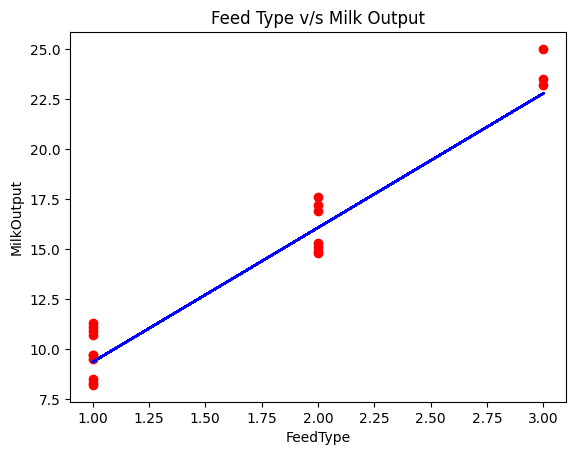

In [77]:
import matplotlib.pyplot as plt
plt.scatter(X_test,y_test,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("Feed Type v/s Milk Output")
plt.xlabel("FeedType")
plt.ylabel('MilkOutput')
plt.show()

In [78]:
#Multiple Linear Regression
X = df[['FeedType', 'FeedQty']]
y = df['MilkOutput']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_predHD=model.predict([[30.8,10.9]])
print(y_predHD)

y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

# Error calculations
print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

Intercept: -8.101015922412522
Coefficients: [-0.46821864  2.25858657]
[2.09644374]
Predicted: [23.24383346 15.35528178  8.82188204 15.80699909 17.16215104]
Actual: [23.5 15.2  8.4 16.7 17.5]
MAE: 0.319044279152795
MSE: 0.14356597185393832
RMSE: 0.37890100534828136
R2 Score: 0.9943309398574328


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


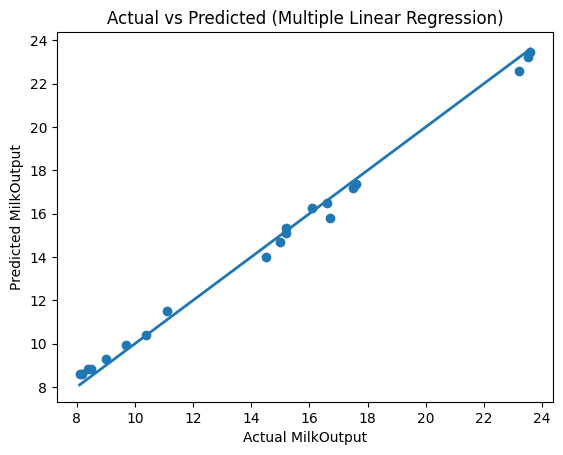

In [79]:
import matplotlib.pyplot as plt

# Predict on test data
y_pred = model.predict(X_test)

# Scatter plot
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual MilkOutput")
plt.ylabel("Predicted MilkOutput")
plt.title("Actual vs Predicted (Multiple Linear Regression)")

plt.show()

In [80]:
#svm
from sklearn.svm import SVR
X = df[['FeedType', 'FeedQty']]
y = df['MilkOutput']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = SVR(kernel='rbf')
#model = SVR(kernel='linear')
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
#print("Coefficients:", model.coef_)  #coef_ is only available when using a linear kernel

y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

# Error calculations
print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

Intercept: [16.28895989]
Predicted: [14.13564384 16.93440276 10.6249682  21.60245724 24.52618047]
Actual: [14.8 16.6 11.  19.7 27. ]
MAE: 0.8032951151601473
MSE: 1.1906286125878425
RMSE: 1.0911592975307696
R2 Score: 0.9491488591189954


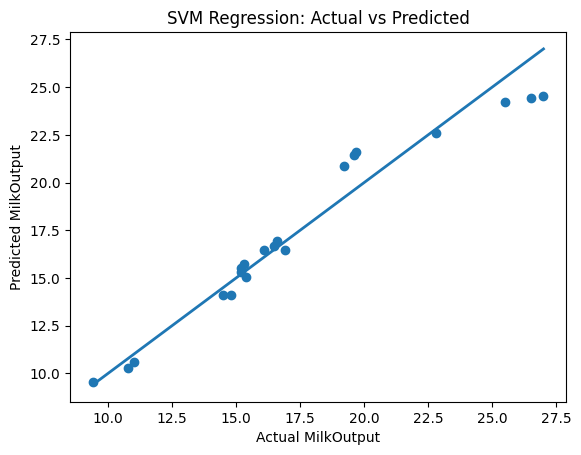

In [81]:
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Scatter plot
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual MilkOutput")
plt.ylabel("Predicted MilkOutput")
plt.title("SVM Regression: Actual vs Predicted")

plt.show()

In [82]:
#Artificail Neural Network
from sklearn.neural_network import MLPRegressor

X = df[['FeedType', 'FeedQty']]
y = df['MilkOutput']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MLPRegressor(hidden_layer_sizes=(6,6), max_iter=500)
#Two hidden layers with 6 neurons each
#Number of training iterations
model.fit(X_train, y_train)


y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

# Error calculations
print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

Predicted: [8.51255203 5.96969593 7.83759031 8.70539824 6.01790748]
Actual: [25.2 14.5 22.3 26.  14.6]
MAE: 11.427910154490984
MSE: 149.16700408995126
RMSE: 12.213394454039028
R2 Score: -3.7075328220265105


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


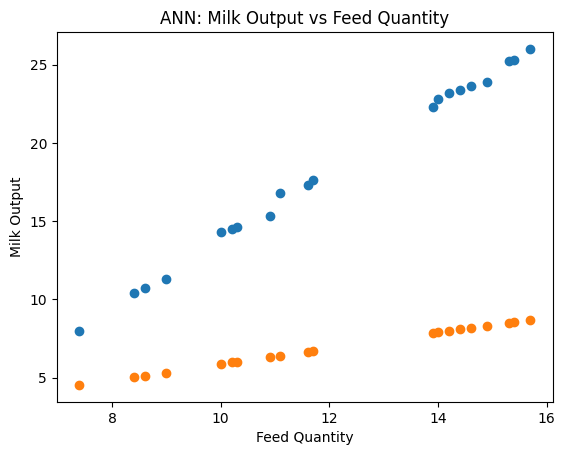

In [83]:
plt.scatter(X_test['FeedQty'], y_test)       # actual
plt.scatter(X_test['FeedQty'], y_predHD)     # predicted

plt.xlabel("Feed Quantity")
plt.ylabel("Milk Output")
plt.title("ANN: Milk Output vs Feed Quantity")

plt.show()

In [84]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

# Error calculations
print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

Predicted: [25.   14.8  22.05 26.2  14.9 ]
Actual: [25.2 14.5 22.3 26.  14.6]
MAE: 0.22249999999999986
MSE: 0.07012499999999995
RMSE: 0.2648112535373071
R2 Score: 0.9977869385983944


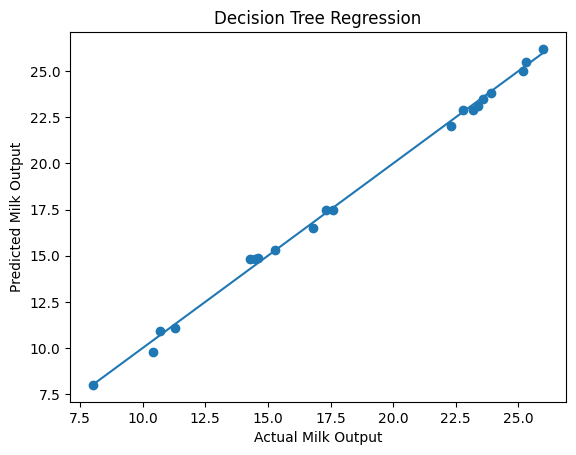

In [85]:
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)])

plt.xlabel("Actual Milk Output")
plt.ylabel("Predicted Milk Output")
plt.title("Decision Tree Regression")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


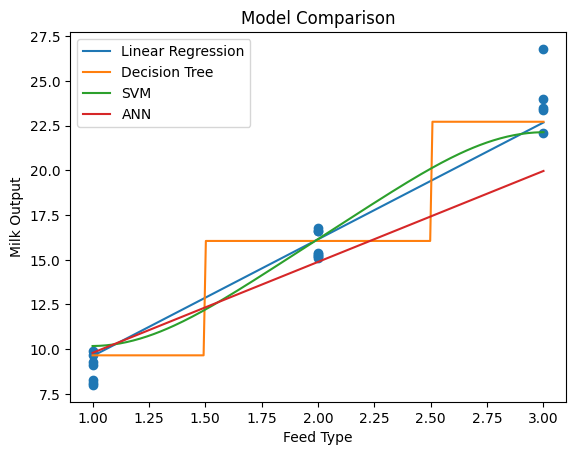

In [86]:
# Use single feature for comparison
X = df[['FeedType']]
y = df['MilkOutput']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

lr = LinearRegression()
dt = DecisionTreeRegressor()
svm = SVR(kernel='rbf')
ann = MLPRegressor(hidden_layer_sizes=(6,6), max_iter=500)

# Train
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
svm.fit(X_train, y_train)
ann.fit(X_train, y_train)

# Smooth X for plotting
X_grid = np.linspace(X.min(), X.max(), 200).reshape(-1,1)

# Plot
plt.scatter(X_test, y_test)  # actual data

plt.plot(X_grid, lr.predict(X_grid), label="Linear Regression")
plt.plot(X_grid, dt.predict(X_grid), label="Decision Tree")
plt.plot(X_grid, svm.predict(X_grid), label="SVM")
plt.plot(X_grid, ann.predict(X_grid), label="ANN")

plt.title("Model Comparison")
plt.xlabel("Feed Type")
plt.ylabel("Milk Output")

plt.legend()
plt.show()

In [87]:
from sklearn.metrics import r2_score, mean_squared_error

# Features and target
X = df[['FeedType']]   # change if needed
y = df['MilkOutput']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "SVM": SVR(),
    "ANN": MLPRegressor(hidden_layer_sizes=(6,6), max_iter=500)
}

# Train and evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    results.append([name, r2, rmse])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])

# Show results
print(results_df.sort_values(by="R2 Score", ascending=False))

               Model  R2 Score      RMSE
1      Decision Tree  0.941101  1.465589
0  Linear Regression  0.940472  1.473387
2                SVM  0.925988  1.642896
3                ANN  0.784192  2.805380


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


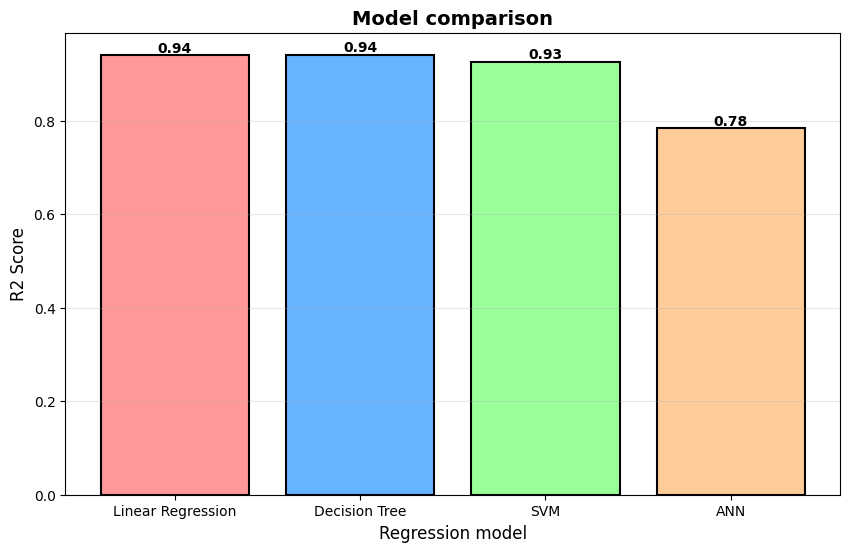

In [88]:
#model comparison
colors_list = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
plt.figure(figsize=(10, 6))
bars=plt.bar(results_df["Model"], results_df["R2 Score"],color=colors_list,edgecolor='black',linewidth=1.5)
plt.xlabel('Regression model', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)
plt.title('Model comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

In [70]:
#Hyperparameter tuning
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Model
dt = DecisionTreeRegressor(random_state=50)

# Hyperparameter grid
param_grid = {
    'max_depth': [None, 2, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt',None]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_dt = grid_search.best_estimator_

# Predictions
y_pred = best_dt.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae= mean_absolute_error(y_test,y_pred)

print("Tuned R2 Score:", r2)
print("Tuned RMSE:", rmse)
print("Tuned MAE",mae)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Tuned R2 Score: 0.9411008578908248
Tuned RMSE: 1.465588657059505
Tuned MAE 1.201016483516483


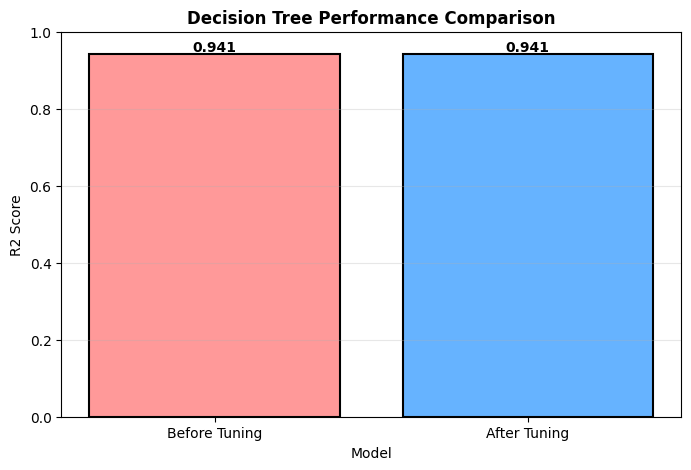

In [71]:
import matplotlib.pyplot as plt

# Before tuning (your original model)
from sklearn.tree import DecisionTreeRegressor

dt_default = DecisionTreeRegressor(random_state=42)
dt_default.fit(X_train, y_train)

y_pred_default = dt_default.predict(X_test)

r2_default = r2_score(y_test, y_pred_default)
rmse_default = mean_squared_error(y_test, y_pred_default) ** 0.5

# After tuning (already done)
r2_tuned = r2
rmse_tuned = rmse

# Data for plotting
models = ['Before Tuning', 'After Tuning']
r2_scores = [r2_default, r2_tuned]

# Plot R2 comparison
plt.figure(figsize=(8,5))
bars = plt.bar(models, r2_scores, color=colors_list,edgecolor='black', linewidth=1.5)

plt.title('Decision Tree Performance Comparison', fontweight='bold')
plt.ylabel('R2 Score')
plt.xlabel('Model')

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()